In [1]:
import numpy as np
import networkx as nx

import os

from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.iterative_searcher import IterativeSearcher

from recover_dwave_inspector_data import recover_dwave_inspector_problems_from_runs


%load_ext autoreload
%autoreload 2

In [2]:
graphs_er = np.load("../Tutorials/ER/resolution-1/graphs-1_p-0.4.npy", allow_pickle=True)
graphs_er = [g[0] for g in graphs_er]
graphs_er_110_160 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_110-160.npy", allow_pickle=True)
g_er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)
graphs_er = graphs_er + graphs_er_110_160.tolist() + g_er_169.tolist()

graphs_pwl = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs_pwl = [g[0] for g in graphs_pwl]
graphs_pwl_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True)
g_pwl_169 = np.load("graphs/powerlaw_110-160/powerlaw_graph_169.npy", allow_pickle=True)
graphs_pwl = graphs_pwl + graphs_pwl_110_160.tolist() + g_pwl_169.tolist()

In [3]:
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4"
results_dir_pwl = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"

In [4]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
from saving_utils import parse_response_json
import numpy as np

graphs_results_er = {}

num_runs = 20
graphs_sizes = [int(g.number_of_nodes()) for g in graphs_er]  # 10-160 + 169

for g_size in graphs_sizes:
    hierarchical_metadatas = []
    path = results_dir_er + f"/graph_size={g_size}"

    for iter in range(num_runs):
        base_filename = f"{path}/er_p=0.4_iter_{iter}"
        hm = HierarchicalRunMetadata.load_from_files(base_filename)
        hierarchical_metadatas.append(hm)

    if g_size == 169:
        # runs-5-extra
        path_5 = f"{results_dir_er}/runs-5-extra/erdos-renyi_169/graph_size=169"
        for iter in range(5):
            base_filename = f"{path_5}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        # runs-20
        path_20 = f"{results_dir_er}/runs-20/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-20-extra
        path_20_extra = f"{results_dir_er}/runs-20-extra/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-55-extra
        path_55_extra = f"{results_dir_er}/runs-55-extra/erdos-renyi_169/graph_size=169"
        for iter in range(55):
            base_filename = f"{path_55_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        communities_list = []
        modularities_list = []
        times_list = []
        div_mods_list = []
        div_trees_list = []

        for p in [path_5, path_20, path_20_extra, path_55_extra]:
            communities_list.append(np.load(f"{p}/er_p=0.4_communities.npy", allow_pickle=True))
            modularities_list.append(np.load(f"{p}/er_p=0.4_modularities.npy", allow_pickle=True))
            times_list.append(np.load(f"{p}/er_p=0.4_times.npy", allow_pickle=True))
            div_mods_list.append(np.load(f"{p}/er_p=0.4_division_modularities.npy", allow_pickle=True))
            div_trees_list.append(np.load(f"{p}/er_p=0.4_division_trees.npy", allow_pickle=True))

        communities = np.concatenate(communities_list, axis=0)
        modularities = np.concatenate(modularities_list, axis=0)
        times = np.concatenate(times_list, axis=0)
        division_modularities = np.concatenate(div_mods_list, axis=0)
        division_trees = np.concatenate(div_trees_list, axis=0)

    else:
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref=graphs_er[graphs_sizes.index(g_size)],
        graph_size=g_size,
        communities=communities,
        modularities=modularities,
        times=times,
        division_modularities=division_modularities,
        division_trees=division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_er[g_size] = iterative_graph_results

In [127]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results_pwl = {}

num_runs = 20
graph_sizes = [int(g.number_of_nodes()) for g in graphs_er] # 10-160 + 169
base = f"./{results_dir_pwl}"


for g_size in graph_sizes:
    path = base + f"/graph_size={g_size}/"
    communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
    modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
    times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
    division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
    division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(3):
            base_filename = f"{path}-ex4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(21, 24, 1):
            base_filename = f"{path}-3runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = communities[:-4]
        modularities = modularities[:-4]
        times = times[:-4]
        division_modularities = division_modularities[:-4]
        division_trees = division_trees[:-4]

        communities = np.concatenate((communities, comms_3), axis=0)
        modularities = np.concatenate((modularities, mods_3), axis=0)
        times = np.concatenate((times, times_3), axis=0)
        division_modularities = np.concatenate((division_modularities, div_mods_3), axis=0)
        division_trees = np.concatenate((division_trees, div_trees_3), axis=0)

    elif g_size == 169:
        # -----------------------------
        # 169-extra-20runs
        # -----------------------------
        path_20 = path = base + f"/graph_size={g_size}-extra-20runs"
        for iter in range(20):
            base_filename = f"{path_20}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        # -----------------------------
        # 169-extra-30runs
        # -----------------------------
        path_30 = path = base + f"/graph_size={g_size}-extra-30runs"
        for iter in range(30):
            base_filename = f"{path_30}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = np.concatenate((comms_20, comms_30), axis=0)
        modularities = np.concatenate((mods_20, mods_30), axis=0)
        times = np.concatenate((times_20, times_30), axis=0)
        division_modularities = np.concatenate((div_mods_20, div_mods_30), axis=0)
        division_trees = np.concatenate((div_trees_20, div_trees_30), axis=0)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = communities,
        modularities = modularities,
        times = times,
        division_modularities = division_modularities,
        division_trees = division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_pwl[g_size] = iterative_graph_results

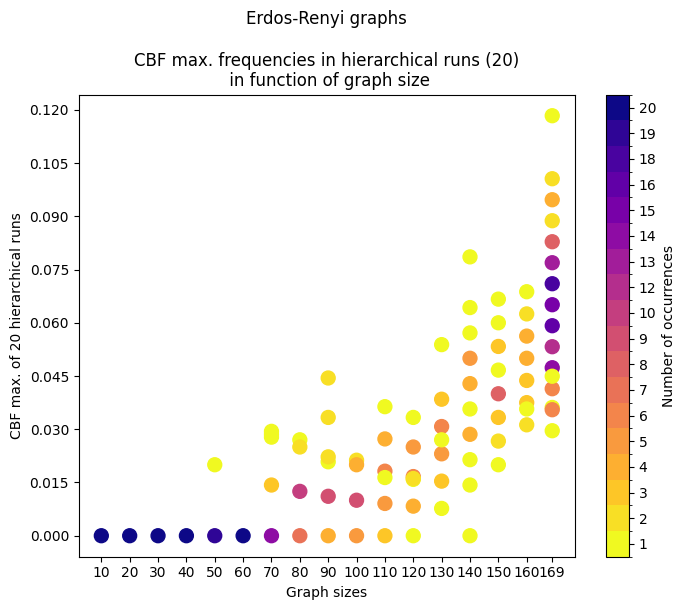

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_er[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))

cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Erdos-Renyi graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))


cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()


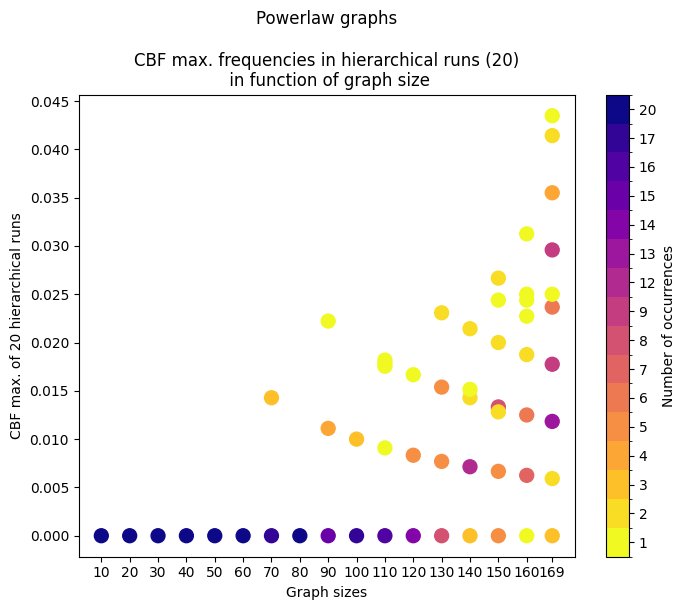

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_pwl[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))

cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Powerlaw graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()

In [131]:
# Power-law
hierarchical_metadata_pwl = graphs_results_pwl[169].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
modularities_pwl = graphs_results_pwl[169].modularities
communities_pwl = graphs_results_pwl[169].communities
cbfs_sums_pwl = graphs_results_pwl[169].cbfs_sum_per_run

# Erdos-Renyi
hierarchical_metadata_er = graphs_results_er[169].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
modularities_er = graphs_results_er[169].modularities
communities_er = graphs_results_er[169].communities
cbfs_sums_er = graphs_results_er[169].cbfs_sum_per_run

In [132]:
# Power-law 
mods_pwl = []
cbf_max_pwl = []
cbf_avg_pwl = []
non_zero_cbfs_pwl = []
chain_strengths_pwl = []
comms_lens_pwl = []
energies_pwl = []
indices_pwl = []

for idx, sm in enumerate(hierarchical_metadata_pwl):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    if modularities_pwl[idx] is None:
        print(f"Skipping idx {idx} with modularity {modularities_pwl[idx]}")
        continue
    cbf_max_pwl.append(cbfs.max())
    cbf_avg_pwl.append(cbfs.mean())
    non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
    indices_pwl.append(non_zero_cbfs_idxs)

    chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_pwl.append(modularities_pwl[idx])
    comms_lens_pwl.append(communities_pwl[idx])


# Erdos-Renyi
mods_er = []
cbf_max_er = []
cbf_avg_er = []
non_zero_cbfs_er = []
chain_strengths_er = []
comms_lens_er = []
energies_er = []
indices_er = []

for idx, sm in enumerate(hierarchical_metadata_er[:-20]):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max_er.append(cbfs.max())
    cbf_avg_er.append(cbfs.mean())
    non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
    indices_er.append(non_zero_cbfs_idxs)

    chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_er.append(modularities_er[idx])
    comms_lens_er.append(communities_er[idx])

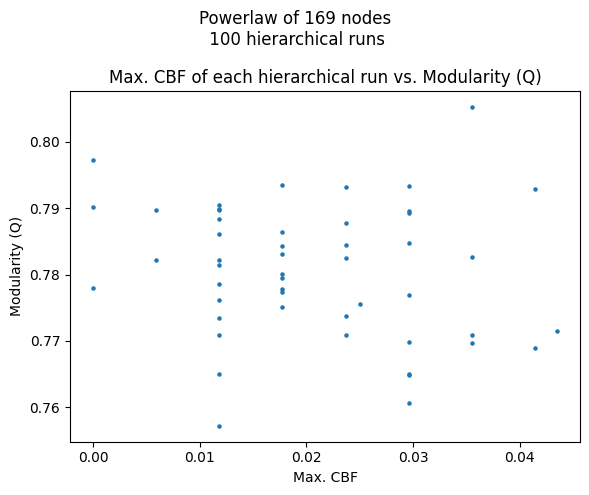

In [133]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Powerlaw of 169 nodes\n 100 hierarchical runs")

ax.scatter(cbf_max_pwl, mods_pwl, s=5)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

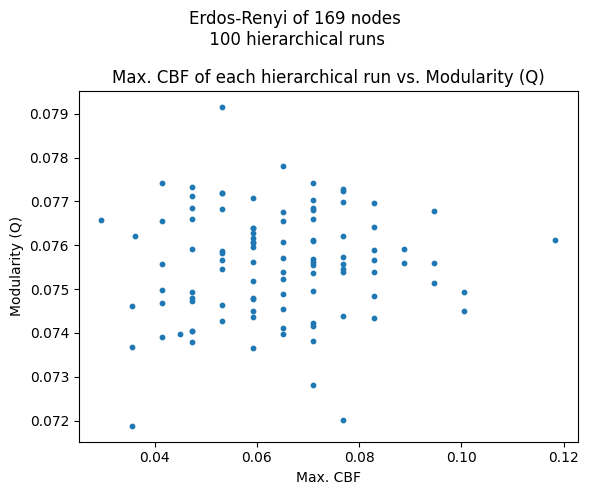

In [134]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Erdos-Renyi of 169 nodes\n 100 hierarchical runs")

sc = ax.scatter(cbf_max_er, mods_er, s=10)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

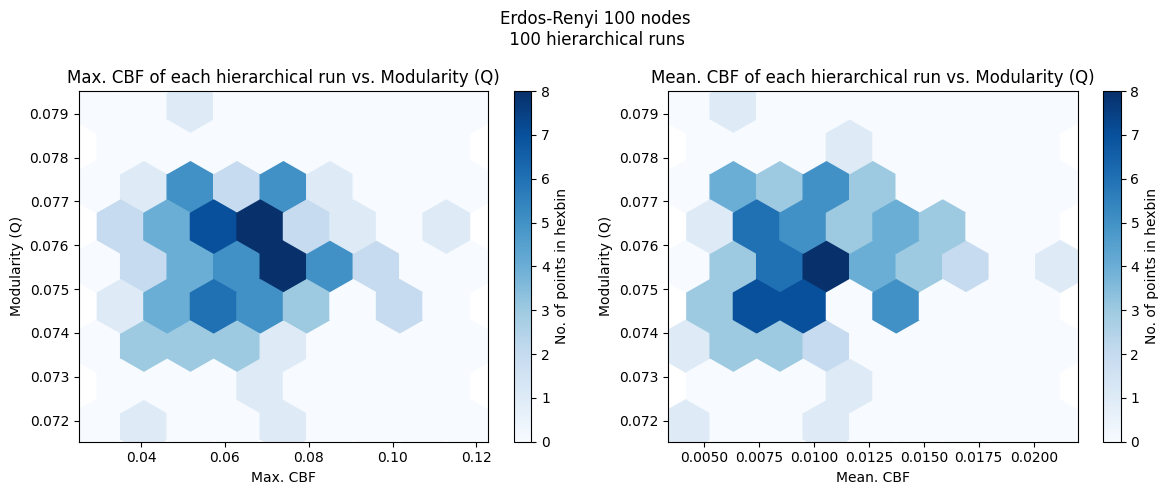

In [135]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Erdos-Renyi 100 nodes\n 100 hierarchical runs")

hb_0 = ax[0].hexbin(cbf_max_er, mods_er, cmap="Blues", gridsize=8)
cb = fig.colorbar(hb_0, ax=ax[0])
cb.set_label("No. of points in hexbin")
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

hb_1 = ax[1].hexbin(cbf_avg_er, mods_er, cmap="Blues", gridsize=8)
cb = fig.colorbar(hb_1, ax=ax[1])
cb.set_label("No. of points in hexbin")
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

In [102]:
y_pwl

array([0.78973569, 0.77793722, 0.79329649, 0.7709042 , 0.77944303,
       0.77864583, 0.78264952, 0.79347364, 0.76070011, 0.76498724,
       0.77382724, 0.77556335, 0.76899093, 0.79019629, 0.78932823,
       0.78473994,        nan,        nan,        nan,        nan,
       0.79283588, 0.78015164, 0.78450964, 0.78959396, 0.76973498,
       0.77347293, 0.78311012, 0.7750496 , 0.7821712 , 0.77150652,
       0.78222435, 0.80521896, 0.75722789, 0.79730017, 0.77788407,
       0.78610402, 0.77093963, 0.77613024, 0.79311933, 0.78436791,
       0.78142715, 0.78973569, 0.79047973, 0.77742347, 0.78833617,
       0.78250779, 0.76991213, 0.77085105, 0.78982426, 0.77685658])

ER: Pearson r = 0.069, p-value = 0.496
PWL: Pearson r = -0.166, p-value = 0.251

ER: Spearman corr = 0.072, p-value = 0.479
PWL: Spearman corr = -0.190, p-value = 0.186


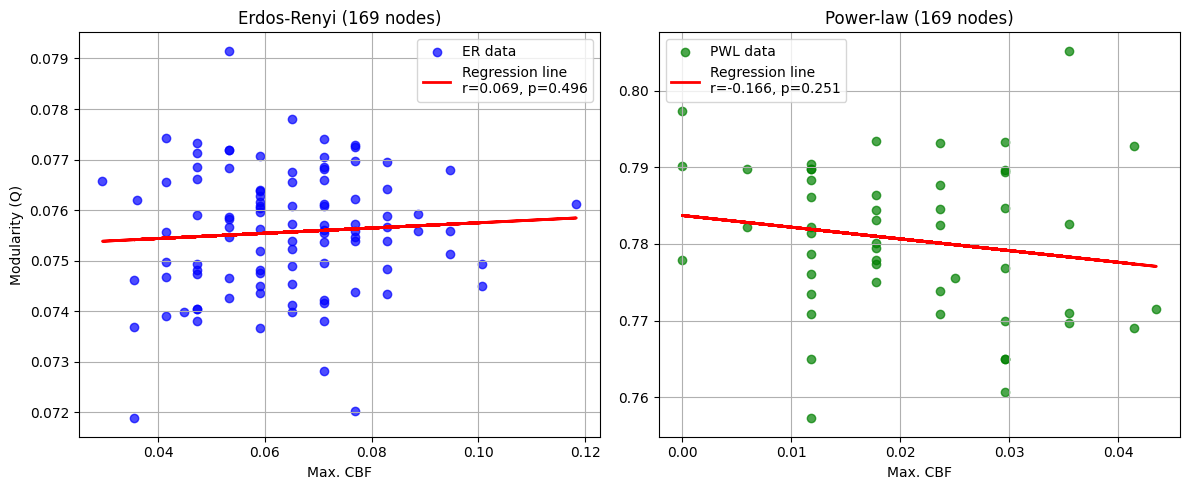

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr


x_er = np.array(cbf_max_er)
y_er = np.array(mods_er)

x_pwl = np.array(cbf_max_pwl)
y_pwl = np.array(mods_pwl)

r_er, p_er = pearsonr(x_er, y_er)
r_pwl, p_pwl = pearsonr(x_pwl, y_pwl)

print(f"ER: Pearson r = {r_er:.3f}, p-value = {p_er:.3f}")
print(f"PWL: Pearson r = {r_pwl:.3f}, p-value = {p_pwl:.3f}")
print()

corr_er, pval_er = spearmanr(x_er, y_er)
corr_pwl, pval_pwl = spearmanr(x_pwl, y_pwl)

print(f"ER: Spearman corr = {corr_er:.3f}, p-value = {pval_er:.3f}")
print(f"PWL: Spearman corr = {corr_pwl:.3f}, p-value = {pval_pwl:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(x_er, y_er, color='blue', alpha=0.7, label='ER data')
m_er, b_er = np.polyfit(x_er, y_er, 1)
axes[0].plot(x_er, m_er*x_er + b_er, color='red', lw=2,
             label=f'Regression line\nr={r_er:.3f}, p={p_er:.3f}')
axes[0].set_xlabel('Max. CBF')
axes[0].set_ylabel('Modularity (Q)')
axes[0].set_title('Erdos-Renyi (169 nodes)')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(x_pwl, y_pwl, color='green', alpha=0.7, label='PWL data')
m_pwl, b_pwl = np.polyfit(x_pwl, y_pwl, 1)
axes[1].plot(x_pwl, m_pwl*x_pwl + b_pwl, color='red', lw=2,
             label=f'Regression line\nr={r_pwl:.3f}, p={p_pwl:.3f}')
axes[1].set_xlabel('Max. CBF')
axes[1].set_title('Power-law (169 nodes)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [137]:
from Qommunity.samplers.regular.leiden_sampler import LeidenSampler
from Qommunity.searchers.regular_searcher import RegularSearcher
from Qommunity.iterative_searcher import IterativeSearcher

num_runs = 100

results_leid_er = {}
for G, g_size in zip(graphs_er, graph_sizes):
    it_searcher = IterativeSearcher(LeidenSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    
    comms, mods, times = res
    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_leid_er[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_leid_er = [results_leid_er[g_size]["modularities"] for g_size in graph_sizes]


results_leid_pwl = {}
for G, g_size in zip(graphs_pwl, graph_sizes):
    it_searcher = IterativeSearcher(LeidenSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res

    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_leid_pwl[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_leid_pwl = [results_leid_pwl[g_size]["modularities"] for g_size in graph_sizes]


from Qommunity.samplers.regular.louvain_sampler import LouvainSampler


results_louv_er = {}
for G, g_size in zip(graphs_er, graph_sizes):
    it_searcher = IterativeSearcher(LouvainSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res

    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_louv_er[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_louv_er = [results_louv_er[g_size]["modularities"] for g_size in graph_sizes]

results_louv_pwl = {}
for G, g_size in zip(graphs_pwl, graph_sizes):
    it_searcher = IterativeSearcher(LouvainSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res
    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_louv_pwl[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_louv_pwl = [results_louv_pwl[g_size]["modularities"] for g_size in graph_sizes]

100%|██████████| 100/100 [00:00<00:00, 133.66it/s]


In [87]:
results_mod_maxes_er = {}
results_mod_maxes_pwl = {}
for gsize in graph_sizes:
    results_mod_maxes_er[gsize] = max(graphs_results_er[gsize].modularities)
    results_mod_maxes_pwl[gsize] = max(graphs_results_pwl[gsize].modularities)

ValueError: x and y must be the same size

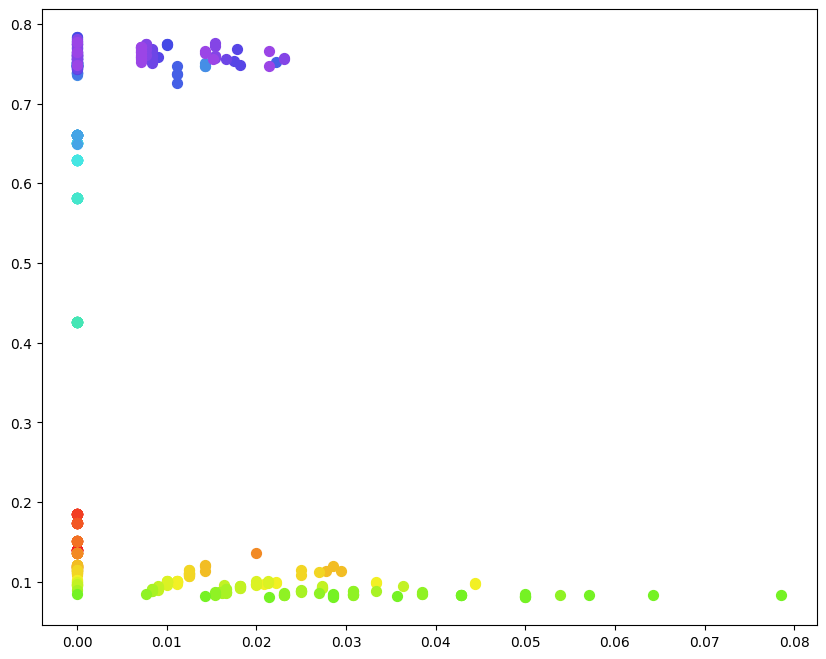

In [89]:
import matplotlib.pyplot as plt
import numpy as np

n_sizes = len(graph_sizes)

pwl_cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_sizes))
er_cmap  = plt.cm.plasma(np.linspace(0.2, 0.9, n_sizes))

import matplotlib.colors as mcolors
import numpy as np

# def make_palette(n, hue_range=(0.0, 1.0), s=0.7, v=0.9):
#     """
#     Generuje n wyraźnie różnych kolorów w danym zakresie hue.
#     hue_range: tuple(start, end) w zakresie 0-1
#     """
#     hues = np.linspace(hue_range[0], hue_range[1], n, endpoint=False)
#     return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

# n_sizes = len(graph_sizes)

# # PWL: odcienie zimne (zielono-niebieskie)
# pwl_colors = make_palette(n_sizes, hue_range=(0.5, 0.7))

# # ER: odcienie ciepłe (czerwono-pomarańczowe)
# er_colors = make_palette(n_sizes, hue_range=(0.0, 0.1))
import matplotlib.colors as mcolors
import numpy as np

# def make_contrasted_palette(n, hue_start=0, hue_end=1, s=0.7, v=0.9):
#     """
#     Generuje n kolorów maksymalnie różniących się w obrębie jednego zakresu hue.
#     hue_start, hue_end ∈ [0,1] - zakres barw w kole HSV
#     """
#     if n == 1:
#         hues = [(hue_start + hue_end)/2]
#     else:
#         hues = np.linspace(hue_start, hue_end, n, endpoint=False)
#     return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

# n_sizes = len(graph_sizes)
# pwl_colors = make_contrasted_palette(n_sizes, hue_start=0.5, hue_end=0.75)
# er_colors  = make_contrasted_palette(n_sizes, hue_start=0.0, hue_end=0.15)
import matplotlib.colors as mcolors
import numpy as np

def generate_contrasted_palettes(n_sizes):
    """
    Generuje dwie wyraźnie różne palety kolorów:
    - pwl_colors: zimne odcienie (cyjan -> niebieski -> fiolet)
    - er_colors: ciepłe odcienie (czerwony -> pomarańcz -> żółty)

    n_sizes: liczba serii / graph_sizes
    Returns: (pwl_colors, er_colors) listy RGB
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # Zimne odcienie dla PWL
    pwl_colors = make_palette(n_sizes, hue_start=0.5, hue_end=0.75, s=0.7, v=0.9)

    # Ciepłe odcienie dla ER
    er_colors  = make_palette(n_sizes, hue_start=0.0, hue_end=0.15, s=0.8, v=0.95)

    return pwl_colors, er_colors

n_sizes = len(graph_sizes)
pwl_colors, er_colors = generate_contrasted_palettes(n_sizes)

import matplotlib.colors as mcolors
import numpy as np


def generate_strongly_contrasted_palettes(n_sizes):
    """
    Generuje dwie palety kolorów:
    - pwl_colors: zimne odcienie (cyjan → niebieski → fiolet)
    - er_colors: ciepłe odcienie (czerwony → pomarańcz → żółty)
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # PWL – zimne kolory (szerszy zakres)
    pwl_colors = make_palette(n_sizes, hue_start=0.45, hue_end=0.85, s=0.7, v=0.9)

    # ER – ciepłe kolory (szerszy zakres)
    er_colors = make_palette(n_sizes, hue_start=0.0, hue_end=0.35, s=0.85, v=0.95)

    return pwl_colors, er_colors

pwl_colors, er_colors = generate_strongly_contrasted_palettes(n_sizes)

num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
    modularities_pwl = graphs_results_pwl[gsize].modularities
    communities_pwl = graphs_results_pwl[gsize].communities
    cbfs_sums_pwl = graphs_results_pwl[gsize].cbfs_sum_per_run

    # Erdos-Renyi
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
    modularities_er = graphs_results_er[gsize].modularities
    communities_er = graphs_results_er[gsize].communities
    cbfs_sums_er = graphs_results_er[gsize].cbfs_sum_per_run

    # Power-law 
    mods_pwl = []
    cbf_max_pwl = []
    cbf_avg_pwl = []
    non_zero_cbfs_pwl = []
    chain_strengths_pwl = []
    comms_lens_pwl = []
    energies_pwl = []
    indices_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_pwl.append(cbfs.max())
        cbf_avg_pwl.append(cbfs.mean())
        non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
        indices_pwl.append(non_zero_cbfs_idxs)

        chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        if idx >= len(modularities_pwl):
            continue
        mods_pwl.append(modularities_pwl[idx])
        comms_lens_pwl.append(communities_pwl[idx])

    # Erdos-Renyi 
    mods_er = []
    cbf_max_er = []
    cbf_avg_er = []
    non_zero_cbfs_er = []
    chain_strengths_er = []
    comms_lens_er = []
    energies_er = []
    indices_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_er.append(cbfs.max())
        cbf_avg_er.append(cbfs.mean())
        non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
        indices_er.append(non_zero_cbfs_idxs)

        chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_er.append(modularities_er[idx])
        comms_lens_er.append(communities_er[idx])

    # pwl_color = pwl_cmap[gi]
    # er_color  = er_cmap[gi]
    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}")
    ax.scatter(cbf_max_er, mods_er, s=50, color=er_color, label=f"ER N={gsize}")

    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []
    cbf_avg_er = []
    non_zero_cbfs_er = []
    chain_strengths_er = []
    comms_lens_er = []
    energies_er = []
    indices_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_er.append(cbfs.max())
        cbf_avg_er.append(cbfs.mean())
        non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
        indices_er.append(non_zero_cbfs_idxs)

        chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_er.append(modularities_er[idx])
        comms_lens_er.append(communities_er[idx])

    # ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
    # ax[1].scatter(cbf_avg_er, mods_er, s=100)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");

# ax.legend(title="Graph size")

# ax.set_yscale("log")

ax.relim()
ax.autoscale_view()

xmin, xmax = ax.get_xlim()



# ax.legend(
#     title="Graph sizes",
#     loc="upper left",
#     bbox_to_anchor=(-0.3, 0.9),
#     borderaxespad=0
# )
handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

# ax.set_yscale("log")

# Zakres osi X
xmin, xmax = ax.get_xlim()

# # Linie dla Power-law
# for i, gsize in enumerate(graph_sizes):
#     ax.hlines(
#         y=max_mods_pwl[i],
#         xmin=xmin,
#         xmax=xmax,
#         colors=pwl_colors[i],
#         linestyles="dashed",
#         linewidth=2,
#         alpha=0.7,
#         label=f"PWL Louvain max N={gsize}"
#     )



# # Linie dla Erdős–Rényi
# for i, gsize in enumerate(graph_sizes):
#     ax.hlines(
#         y=mods_leid_er[i],
#         xmin=xmin,
#         xmax=xmax,
#         colors=er_colors[i],
#         # linestyles="dotted",
#         linewidth=2,
#         alpha=0.35,
#         label=f"ER Louvain max N={gsize}"
#     )

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

In [15]:
graphs_results_pwl[169].modularities

array([0.77683886, 0.78380102, 0.77444728, 0.78528912, 0.76523526,
       0.77613024, 0.78029337, 0.77510275, 0.77605938, 0.77372095,
       0.78606859, 0.76837089, 0.77164824, 0.78151573, 0.7788407 ,
       0.78599773, 0.76271967, 0.77065618, 0.767928  , 0.77368552])

In [16]:
np.array(mods_louv_pwl)

array([0.42592593, 0.58171745, 0.62960761, 0.65023011, 0.6605581 ,
       0.66001149, 0.75078765, 0.74883833, 0.75640702, 0.78262422,
       0.76866425, 0.77886449, 0.78670152, 0.79291962, 0.80142786,
       0.80572367, 0.83039257])

In [19]:
np.array(mods_leid_pwl).mean()

np.float64(0.7183447665618026)

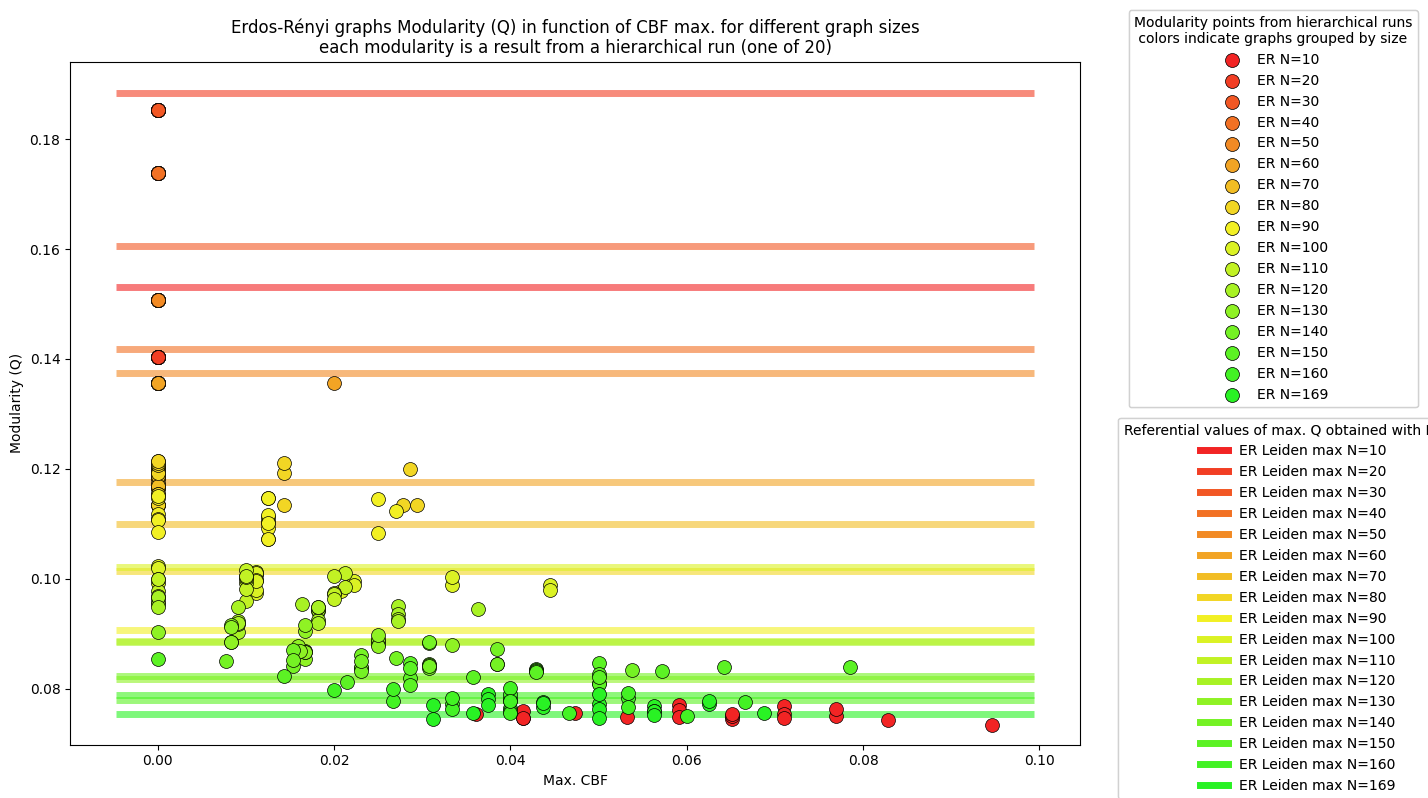

In [31]:
import matplotlib.pyplot as plt
import numpy as np

n_sizes = len(graph_sizes)

pwl_cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_sizes))
er_cmap  = plt.cm.plasma(np.linspace(0.2, 0.9, n_sizes))

import matplotlib.colors as mcolors
import numpy as np


def generate_contrasted_palettes(n_sizes):
    """
    Generuje dwie wyraźnie różne palety kolorów:
    - pwl_colors: zimne odcienie (cyjan -> niebieski -> fiolet)
    - er_colors: ciepłe odcienie (czerwony -> pomarańcz -> żółty)

    n_sizes: liczba serii / graph_sizes
    Returns: (pwl_colors, er_colors) listy RGB
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # Zimne odcienie dla PWL
    pwl_colors = make_palette(n_sizes, hue_start=0.5, hue_end=0.75, s=0.7, v=0.9)

    # Ciepłe odcienie dla ER
    er_colors  = make_palette(n_sizes, hue_start=0.0, hue_end=0.15, s=0.8, v=0.95)

    return pwl_colors, er_colors

n_sizes = len(graph_sizes)
pwl_colors, er_colors = generate_contrasted_palettes(n_sizes)

import matplotlib.colors as mcolors
import numpy as np


def generate_strongly_contrasted_palettes(n_sizes):
    """
    Generuje dwie palety kolorów:
    - pwl_colors: zimne odcienie (cyjan → niebieski → fiolet)
    - er_colors: ciepłe odcienie (czerwony → pomarańcz → żółty)
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # PWL – zimne kolory (szerszy zakres)
    pwl_colors = make_palette(n_sizes, hue_start=0.45, hue_end=0.85, s=0.7, v=0.9)

    # ER – ciepłe kolory (szerszy zakres)
    er_colors = make_palette(n_sizes, hue_start=0.0, hue_end=0.35, s=0.85, v=0.95)

    return pwl_colors, er_colors

pwl_colors, er_colors = generate_strongly_contrasted_palettes(n_sizes)

num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(11, 8), constrained_layout=True)

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
    modularities_pwl = graphs_results_pwl[gsize].modularities
    communities_pwl = graphs_results_pwl[gsize].communities
    cbfs_sums_pwl = graphs_results_pwl[gsize].cbfs_sum_per_run

    # Erdos-Renyi
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
    modularities_er = graphs_results_er[gsize].modularities
    communities_er = graphs_results_er[gsize].communities
    cbfs_sums_er = graphs_results_er[gsize].cbfs_sum_per_run

    # Power-law 
    mods_pwl = []
    cbf_max_pwl = []
    cbf_avg_pwl = []
    non_zero_cbfs_pwl = []
    chain_strengths_pwl = []
    comms_lens_pwl = []
    energies_pwl = []
    indices_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_pwl.append(cbfs.max())
        cbf_avg_pwl.append(cbfs.mean())
        non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
        indices_pwl.append(non_zero_cbfs_idxs)

        chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_pwl.append(modularities_pwl[idx])
        comms_lens_pwl.append(communities_pwl[idx])
    

    # pwl_color = pwl_cmap[gi]
    # er_color  = er_cmap[gi]
    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    # ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}")
    ax.scatter(cbf_max_er, mods_er, s=100, color=er_color, label=f"ER N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)

    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []
    cbf_avg_er = []
    non_zero_cbfs_er = []
    chain_strengths_er = []
    comms_lens_er = []
    energies_er = []
    indices_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_er.append(cbfs.max())
        cbf_avg_er.append(cbfs.mean())
        non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
        indices_er.append(non_zero_cbfs_idxs)

        chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_er.append(modularities_er[idx])
        comms_lens_er.append(communities_er[idx])

    # ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
    # ax[1].scatter(cbf_avg_er, mods_er, s=100)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Erdos-Rényi graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");

# ax.legend(title="Graph size")

# ax.set_yscale("log")

ax.relim()
ax.autoscale_view()

xmin, xmax = ax.get_xlim()



# ax.legend(
#     title="Graph sizes",
#     loc="upper left",
#     bbox_to_anchor=(-0.3, 0.9),
#     borderaxespad=0
# )
handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

# ax.set_yscale("log")

# Zakres osi X
xmin, xmax = ax.get_xlim()


# Linie dla Erdős–Rényi
for i, gsize in enumerate(graph_sizes):
    ax.hlines(
        y=mods_leid_er[i],
        xmin=xmin,
        xmax=xmax,
        colors=er_colors[i],
        # linestyles="dotted",
        linewidth=5,
        alpha=0.6,
        label=f"ER Louvain max N={gsize}"
    )

# line_styles = ['solid', 'dashed', 'dotted', 'dashdot']  # różne style linii
# n_lines = len(graph_sizes)

# for i, gsize in enumerate(graph_sizes):
#     style = line_styles[i % len(line_styles)]  # powtarza style jeśli jest mniej niż graph_sizes
#     ax.hlines(
#         y=mods_leid_er[i],
#         xmin=xmin,
#         xmax=xmax,
#         colors=er_colors[i],
#         linestyles=style,
#         linewidth=5,
#         alpha=1,
#         label=f"ER Louvain max N={gsize}"
#     )
title=f"Modularity points from hierarchical runs\n colors indicate graphs grouped by size"

legend1 = fig.legend(
    ordered_handles,
    ordered_labels,
    loc='upper right',           # punkt odniesienia legendy
    bbox_to_anchor=(1.3, 1),  # x=0.5 (środek), y=1.05 (trochę nad fig)
    # ncol=4,
    # frameon=False
    title=title,
)
ax.add_artist(legend1)

from matplotlib.lines import Line2D


hl_handles = []
hl_labels = []
for i, gsize in enumerate(graph_sizes):
    proxy = Line2D([0], [0], color=er_colors[i], lw=5)
    hl_handles.append(proxy)
    hl_labels.append(f"ER Leiden max N={gsize}")

legend2 = ax.legend(
    hl_handles,
    hl_labels,
    loc='center right',  # You can adjust position
    bbox_to_anchor=(1.4, 0.2),  # outside figure
    title="Referential values of max. Q obtained with Leiden",
    frameon=True
)
ax.add_artist(legend2)


plt.tight_layout()
plt.show()

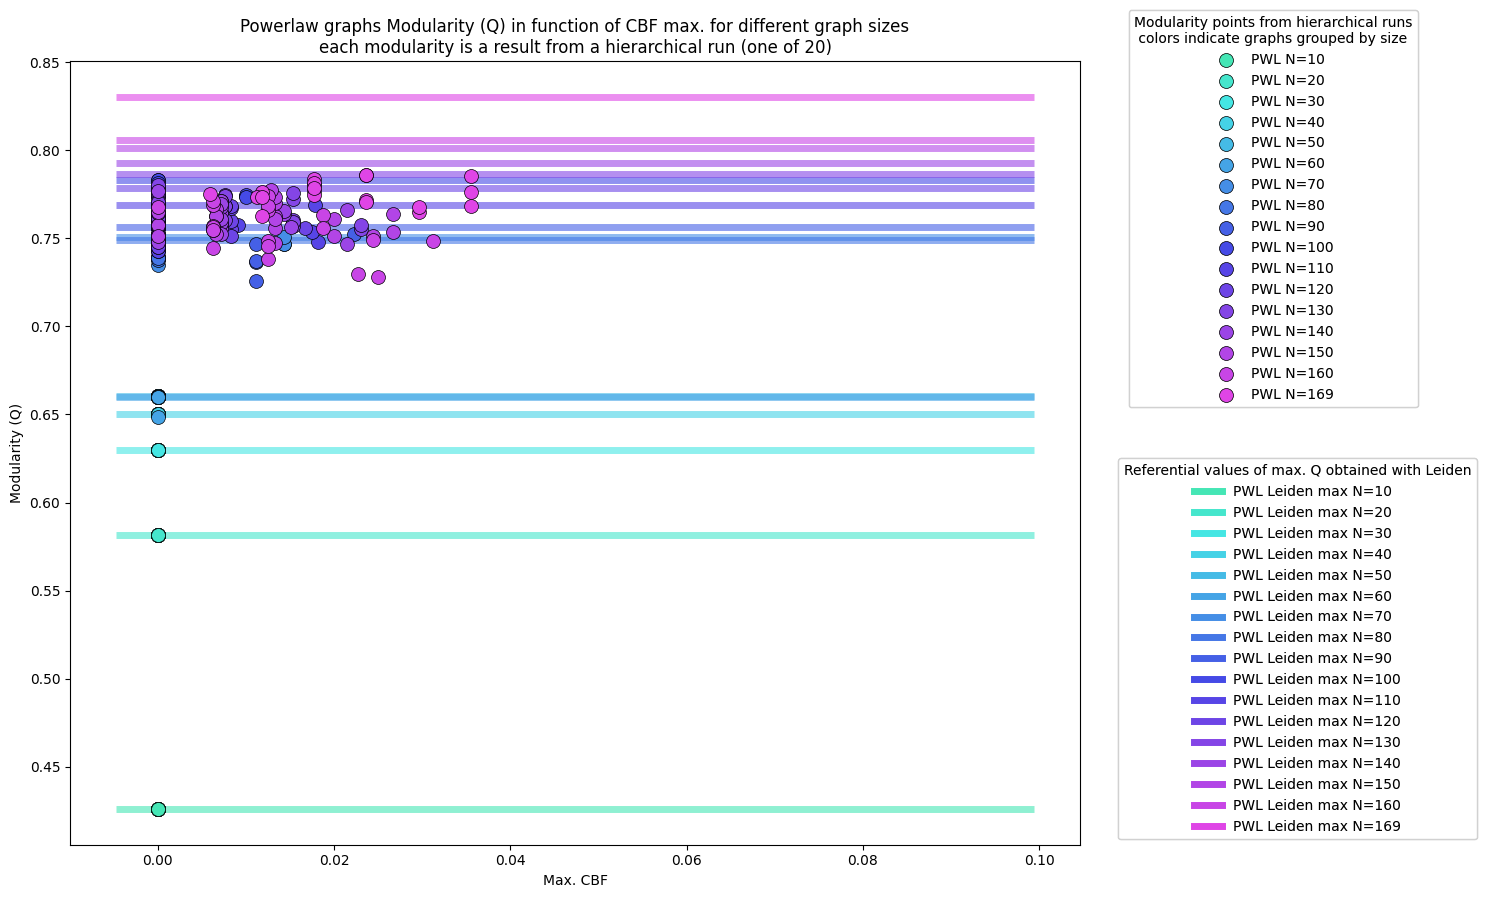

In [37]:
import matplotlib.pyplot as plt
import numpy as np

n_sizes = len(graph_sizes)

pwl_cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_sizes))
er_cmap  = plt.cm.plasma(np.linspace(0.2, 0.9, n_sizes))

import matplotlib.colors as mcolors
import numpy as np


def generate_contrasted_palettes(n_sizes):
    """
    Generuje dwie wyraźnie różne palety kolorów:
    - pwl_colors: zimne odcienie (cyjan -> niebieski -> fiolet)
    - er_colors: ciepłe odcienie (czerwony -> pomarańcz -> żółty)

    n_sizes: liczba serii / graph_sizes
    Returns: (pwl_colors, er_colors) listy RGB
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # Zimne odcienie dla PWL
    pwl_colors = make_palette(n_sizes, hue_start=0.5, hue_end=0.75, s=0.7, v=0.9)

    # Ciepłe odcienie dla ER
    er_colors  = make_palette(n_sizes, hue_start=0.0, hue_end=0.15, s=0.8, v=0.95)

    return pwl_colors, er_colors

n_sizes = len(graph_sizes)
pwl_colors, er_colors = generate_contrasted_palettes(n_sizes)

import matplotlib.colors as mcolors
import numpy as np


def generate_strongly_contrasted_palettes(n_sizes):
    """
    Generuje dwie palety kolorów:
    - pwl_colors: zimne odcienie (cyjan → niebieski → fiolet)
    - er_colors: ciepłe odcienie (czerwony → pomarańcz → żółty)
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # PWL – zimne kolory (szerszy zakres)
    pwl_colors = make_palette(n_sizes, hue_start=0.45, hue_end=0.85, s=0.7, v=0.9)

    # ER – ciepłe kolory (szerszy zakres)
    er_colors = make_palette(n_sizes, hue_start=0.0, hue_end=0.35, s=0.85, v=0.95)

    return pwl_colors, er_colors

pwl_colors, er_colors = generate_strongly_contrasted_palettes(n_sizes)

num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(11, 9), constrained_layout=True)

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
    modularities_pwl = graphs_results_pwl[gsize].modularities
    communities_pwl = graphs_results_pwl[gsize].communities
    cbfs_sums_pwl = graphs_results_pwl[gsize].cbfs_sum_per_run

    # Erdos-Renyi
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
    modularities_er = graphs_results_er[gsize].modularities
    communities_er = graphs_results_er[gsize].communities
    cbfs_sums_er = graphs_results_er[gsize].cbfs_sum_per_run

    # Power-law 
    mods_pwl = []
    cbf_max_pwl = []
    cbf_avg_pwl = []
    non_zero_cbfs_pwl = []
    chain_strengths_pwl = []
    comms_lens_pwl = []
    energies_pwl = []
    indices_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_pwl.append(cbfs.max())
        cbf_avg_pwl.append(cbfs.mean())
        non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
        indices_pwl.append(non_zero_cbfs_idxs)

        chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_pwl.append(modularities_pwl[idx])
        comms_lens_pwl.append(communities_pwl[idx])
    

    # pwl_color = pwl_cmap[gi]
    # er_color  = er_cmap[gi]
    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    # ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}")
    ax.scatter(cbf_max_pwl, mods_pwl, s=100, color=pwl_color, label=f"PWL N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)
    # ax.scatter(cbf_max_er, mods_er, s=100, color=er_color, label=f"ER N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)

    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []
    cbf_avg_er = []
    non_zero_cbfs_er = []
    chain_strengths_er = []
    comms_lens_er = []
    energies_er = []
    indices_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_er.append(cbfs.max())
        cbf_avg_er.append(cbfs.mean())
        non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
        indices_er.append(non_zero_cbfs_idxs)

        chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_er.append(modularities_er[idx])
        comms_lens_er.append(communities_er[idx])

    # ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
    # ax[1].scatter(cbf_avg_er, mods_er, s=100)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");


# ax.set_yscale("log")

# ax.relim()
# ax.autoscale_view()

# xmin, xmax = ax.get_xlim()

handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

# ax.set_yscale("log")

# Linie dla Erdős–Rényi
for i, gsize in enumerate(graph_sizes):
    ax.hlines(
        y=mods_leid_pwl[i],
        xmin=xmin,
        xmax=xmax,
        colors=pwl_colors[i],
        # linestyles="dotted",
        linewidth=5,
        alpha=0.6,
        label=f"PWL Leiden max N={gsize}"
    )

title=f"Modularity points from hierarchical runs\n colors indicate graphs grouped by size"

legend1 = fig.legend(
    ordered_handles,
    ordered_labels,
    loc='upper right',           # punkt odniesienia legendy
    bbox_to_anchor=(1.3, 1),  # x=0.5 (środek), y=1.05 (trochę nad fig)
    # ncol=4,
    # frameon=False
    title=title,
)
ax.add_artist(legend1)

from matplotlib.lines import Line2D


hl_handles = []
hl_labels = []
for i, gsize in enumerate(graph_sizes):
    proxy = Line2D([0], [0], color=pwl_colors[i], lw=5)
    hl_handles.append(proxy)
    hl_labels.append(f"PWL Leiden max N={gsize}")

legend2 = ax.legend(
    hl_handles,
    hl_labels,
    loc='center right',  # You can adjust position
    bbox_to_anchor=(1.4, 0.25),  # outside figure
    title="Referential values of max. Q obtained with Leiden",
    frameon=True
)
ax.add_artist(legend2)


plt.tight_layout()
# plt.show()
plt.savefig("modularity_cbf.svg", format="svg", bbox_inches="tight", pad_inches=1)

<Figure size 640x480 with 0 Axes>

In [108]:
graphs_results_pwl[140].modularities

array([0.76305574, 0.7801356 , 0.75751773, 0.76453082, 0.7623829 ,
       0.75837172, 0.77105222, 0.59541432, 0.74732157, 0.76095958,
       0.76812794, 0.75834584, 0.75529217, 0.764919  , 0.7449925 ,
       0.76051964, 0.76773977, 0.75762124, 0.77384711, 0.76432379])

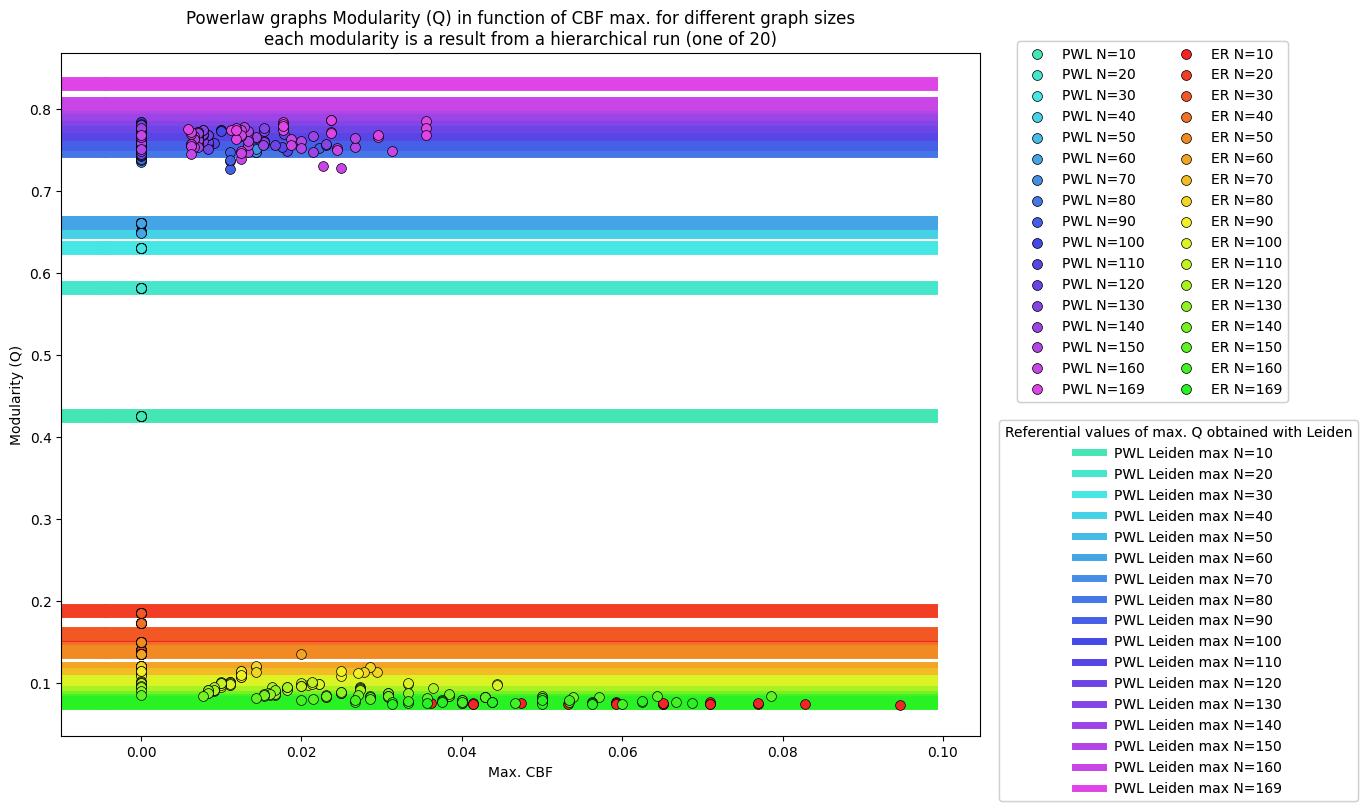

In [22]:
import matplotlib.pyplot as plt
import numpy as np

n_sizes = len(graph_sizes)

pwl_cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_sizes))
er_cmap  = plt.cm.plasma(np.linspace(0.2, 0.9, n_sizes))

import matplotlib.colors as mcolors
import numpy as np

# def make_contrasted_palette(n, hue_start=0, hue_end=1, s=0.7, v=0.9):
#     """
#     Generuje n kolorów maksymalnie różniących się w obrębie jednego zakresu hue.
#     hue_start, hue_end ∈ [0,1] - zakres barw w kole HSV
#     """
#     if n == 1:
#         hues = [(hue_start + hue_end)/2]
#     else:
#         hues = np.linspace(hue_start, hue_end, n, endpoint=False)
#     return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

# n_sizes = len(graph_sizes)
# pwl_colors = make_contrasted_palette(n_sizes, hue_start=0.5, hue_end=0.75)
# er_colors  = make_contrasted_palette(n_sizes, hue_start=0.0, hue_end=0.15)
import matplotlib.colors as mcolors
import numpy as np

def generate_contrasted_palettes(n_sizes):
    """
    Generuje dwie wyraźnie różne palety kolorów:
    - pwl_colors: zimne odcienie (cyjan -> niebieski -> fiolet)
    - er_colors: ciepłe odcienie (czerwony -> pomarańcz -> żółty)

    n_sizes: liczba serii / graph_sizes
    Returns: (pwl_colors, er_colors) listy RGB
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # Zimne odcienie dla PWL
    pwl_colors = make_palette(n_sizes, hue_start=0.5, hue_end=0.75, s=0.7, v=0.9)

    # Ciepłe odcienie dla ER
    er_colors  = make_palette(n_sizes, hue_start=0.0, hue_end=0.15, s=0.8, v=0.95)

    return pwl_colors, er_colors

n_sizes = len(graph_sizes)
pwl_colors, er_colors = generate_contrasted_palettes(n_sizes)

import matplotlib.colors as mcolors
import numpy as np


def generate_strongly_contrasted_palettes(n_sizes):
    """
    Generuje dwie palety kolorów:
    - pwl_colors: zimne odcienie (cyjan → niebieski → fiolet)
    - er_colors: ciepłe odcienie (czerwony → pomarańcz → żółty)
    """
    def make_palette(n, hue_start, hue_end, s=0.7, v=0.9):
        if n == 1:
            hues = [(hue_start + hue_end)/2]
        else:
            hues = np.linspace(hue_start, hue_end, n, endpoint=False)
        return [mcolors.hsv_to_rgb((h, s, v)) for h in hues]

    # PWL – zimne kolory (szerszy zakres)
    pwl_colors = make_palette(n_sizes, hue_start=0.45, hue_end=0.85, s=0.7, v=0.9)

    # ER – ciepłe kolory (szerszy zakres)
    er_colors = make_palette(n_sizes, hue_start=0.0, hue_end=0.35, s=0.85, v=0.95)

    return pwl_colors, er_colors

pwl_colors, er_colors = generate_strongly_contrasted_palettes(n_sizes)

num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
    modularities_pwl = graphs_results_pwl[gsize].modularities
    communities_pwl = graphs_results_pwl[gsize].communities
    cbfs_sums_pwl = graphs_results_pwl[gsize].cbfs_sum_per_run

    # Erdos-Renyi
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    cbfs = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
    modularities_er = graphs_results_er[gsize].modularities
    communities_er = graphs_results_er[gsize].communities
    cbfs_sums_er = graphs_results_er[gsize].cbfs_sum_per_run

    # Power-law 
    mods_pwl = []
    cbf_max_pwl = []
    cbf_avg_pwl = []
    non_zero_cbfs_pwl = []
    chain_strengths_pwl = []
    comms_lens_pwl = []
    energies_pwl = []
    indices_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_pwl.append(cbfs.max())
        cbf_avg_pwl.append(cbfs.mean())
        non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
        indices_pwl.append(non_zero_cbfs_idxs)

        chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_pwl.append(modularities_pwl[idx])
        comms_lens_pwl.append(communities_pwl[idx])
    

    # pwl_color = pwl_cmap[gi]
    # er_color  = er_cmap[gi]
    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)
    ax.scatter(cbf_max_er, mods_er, s=50, color=er_color, label=f"ER N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)

    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []
    cbf_avg_er = []
    non_zero_cbfs_er = []
    chain_strengths_er = []
    comms_lens_er = []
    energies_er = []
    indices_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        cbfs = np.array(sm.chain_break_fraction)
        non_zero_cbfs_idxs = np.where(cbfs > 0)
        cbf_max_er.append(cbfs.max())
        cbf_avg_er.append(cbfs.mean())
        non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
        indices_er.append(non_zero_cbfs_idxs)

        chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
        mods_er.append(modularities_er[idx])
        comms_lens_er.append(communities_er[idx])

    # ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
    # ax[1].scatter(cbf_avg_er, mods_er, s=100)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");


# ax.set_yscale("log")

# ax.relim()
# ax.autoscale_view()

# xmin, xmax = ax.get_xlim()

handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

xmin, xmax = ax.get_xlim()

# Power-law
for i, gsize in enumerate(graph_sizes):
    ax.hlines(
        y=mods_leid_pwl[i],
        xmin=xmin,
        xmax=xmax,
        colors=pwl_colors[i],
        # linestyles="dashed",
        linewidth=10,
        alpha=1,
        label=f"PWL Louvain max N={gsize}",
    )

# Erdős–Rényi
for i, gsize in enumerate(graph_sizes):
    ax.hlines(
        y=mods_leid_er[i],
        xmin=xmin,
        xmax=xmax,
        colors=er_colors[i],
        # linestyles="dotted",
        linewidth=10,
        alpha=1,
        label=f"ER Louvain max N={gsize}",
    )

for i, gsize in enumerate(graph_sizes):
    ax.hlines(
        y=mods_leid_pwl[i],
        xmin=0,
        xmax=0.05,
        transform=ax.get_yaxis_transform(),
        linestyles="dashed",
        colors=pwl_colors[i],
        linewidth=10,
    )
    ax.hlines(
        y=mods_leid_er[i],
        xmin=0,
        xmax=0.05,
        transform=ax.get_yaxis_transform(),
        linestyles="dashed",
        colors=er_colors[i],
        linewidth=10,
    )

legend1 = fig.legend(
    ordered_handles,
    ordered_labels,
    loc='upper right',
    ncol=2,
    bbox_to_anchor=(1.3, 0.95),
    # frameon=False,
)
ax.add_artist(legend1)

hl_handles = []
hl_labels = []
for i, gsize in enumerate(graph_sizes):
    proxy = Line2D([0], [0], color=pwl_colors[i], lw=5)
    hl_handles.append(proxy)
    hl_labels.append(f"PWL Leiden max N={gsize}")

legend2 = fig.legend(
    hl_handles,
    hl_labels,
    loc='center right',  # You can adjust position
    bbox_to_anchor=(1.37, 0.23),  # outside figure
    title="Referential values of max. Q obtained with Leiden",
    frameon=True
)
ax.add_artist(legend2)

plt.tight_layout()
plt.show()

In [223]:
scatter_collections = [
    c for c in ax.collections
    if isinstance(c, plt.matplotlib.collections.PathCollection)
]

n_points = sum(len(c.get_offsets()) for c in scatter_collections)
print("Total scattered points (drawn):", n_points)# 17 x 20 x 2 = 680 | -1 (one run missing)

Total scattered points (drawn): 679
